This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [4]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Introduction to TensorFlow, PyTorch, JAX, and Keras

### A brief history of deep learning frameworks

### How these frameworks relate to each other

### Introduction to TensorFlow

#### First steps with TensorFlow

##### Tensors and variables in TensorFlow

###### Constant tensors

In [5]:
import tensorflow as tf
tf.ones(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [6]:
tf.zeros(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [7]:
tf.constant([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

###### Random tensors

In [8]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[-1.6387326 ]
 [ 1.0693399 ]
 [ 0.35351446]], shape=(3, 1), dtype=float32)


In [9]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.6475247 ]
 [0.01244938]
 [0.31137764]], shape=(3, 1), dtype=float32)


###### Tensor assignment and the Variable class

In [10]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0

In [11]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[0.2061423],
       [1.0445185],
       [1.0903909]], dtype=float32)>


In [12]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [13]:
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [14]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

##### Tensor operations: Doing math in TensorFlow

In [15]:
a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)
f = tf.concat((a, b), axis=0)

In [16]:
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

##### Gradients in TensorFlow: A second look at the GradientTape API

In [17]:
input_var = tf.Variable(initial_value=3.0)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)

In [18]:
input_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

In [19]:
time = tf.Variable(0.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)

In [94]:
x = tf.Variable(initial_value=2.0)
y = tf.Variable(initial_value=1.0)

with tf.GradientTape() as tape:
    result = x**2 * y + x * y + 3 * y

grad_x, grad_y = tape.gradient(result, [x, y])
grad_x, grad_y

(<tf.Tensor: shape=(), dtype=float32, numpy=5.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=9.0>)

In [95]:
x = tf.constant(
    np.array([1., 4., 3.]).reshape(1, 3),
    dtype=tf.float32
)

W = tf.Variable(
    tf.random.uniform((3, 2)),
    dtype=tf.float32
)

b = tf.Variable(
    tf.zeros((2,)),
    dtype=tf.float32
)

with tf.GradientTape() as tape:
    result = tf.matmul(x, W) + b

grad_W, grad_b = tape.gradient(result, [W, b])

grad_W, grad_b

(<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[1., 1.],
        [4., 4.],
        [3., 3.]], dtype=float32)>,
 <tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 1.], dtype=float32)>)

In [96]:
with tf.GradientTape() as tape:
    result = tf.pow(tf.matmul(x, W) + b, 3)

grad_W, grad_b = tape.gradient(result, [W, b])

grad_W, grad_b

(<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[ 47.31343 ,  30.661938],
        [189.25372 , 122.64775 ],
        [141.94029 ,  91.98581 ]], dtype=float32)>,
 <tf.Tensor: shape=(2,), dtype=float32, numpy=array([47.31343 , 30.661938], dtype=float32)>)

##### Making TensorFlow functions fast using compilation

In [20]:
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

In [21]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure TensorFlow

In [22]:
import numpy as np

num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

In [23]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [24]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

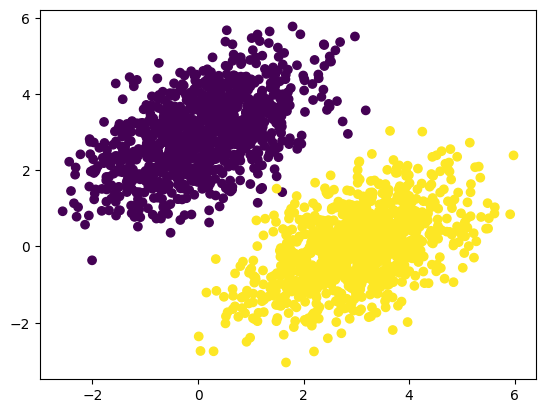

In [25]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [101]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [102]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

In [103]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [104]:
learning_rate = 0.1

@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [105]:
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 0.2389
Loss at step 1: 0.0823
Loss at step 2: 0.0714
Loss at step 3: 0.0667
Loss at step 4: 0.0630
Loss at step 5: 0.0596
Loss at step 6: 0.0566
Loss at step 7: 0.0538
Loss at step 8: 0.0513
Loss at step 9: 0.0490
Loss at step 10: 0.0468
Loss at step 11: 0.0449
Loss at step 12: 0.0432
Loss at step 13: 0.0415
Loss at step 14: 0.0401
Loss at step 15: 0.0387
Loss at step 16: 0.0375
Loss at step 17: 0.0364
Loss at step 18: 0.0353
Loss at step 19: 0.0344
Loss at step 20: 0.0336
Loss at step 21: 0.0328
Loss at step 22: 0.0321
Loss at step 23: 0.0314
Loss at step 24: 0.0308
Loss at step 25: 0.0303
Loss at step 26: 0.0298
Loss at step 27: 0.0293
Loss at step 28: 0.0289
Loss at step 29: 0.0285
Loss at step 30: 0.0282
Loss at step 31: 0.0279
Loss at step 32: 0.0276
Loss at step 33: 0.0273
Loss at step 34: 0.0271
Loss at step 35: 0.0268
Loss at step 36: 0.0266
Loss at step 37: 0.0265
Loss at step 38: 0.0263
Loss at step 39: 0.0261


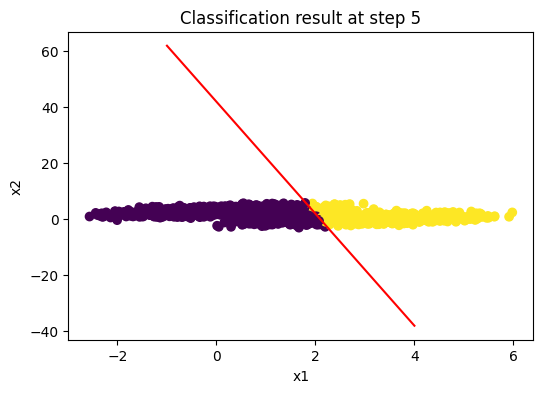

Loss at step 5: 0.1527


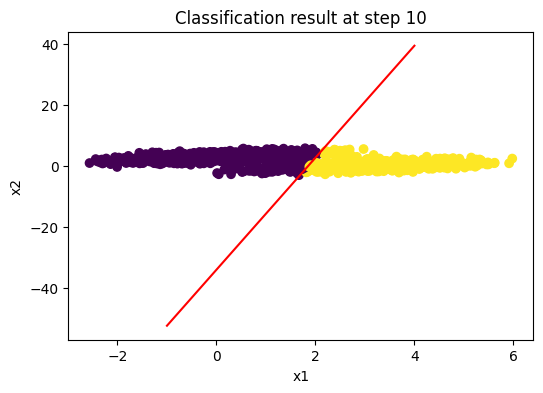

Loss at step 10: 0.1052


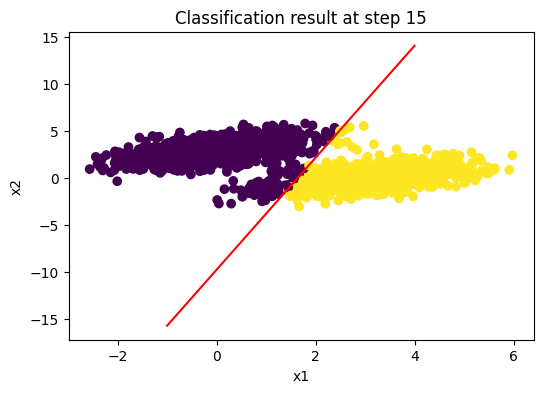

Loss at step 15: 0.0758


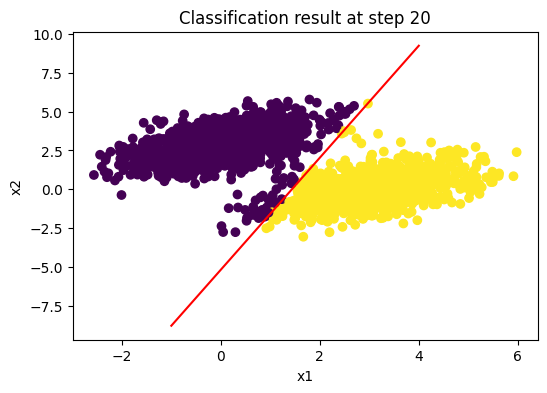

Loss at step 20: 0.0571


In [106]:
# Visualize classification results at steps 5, 10, 15, and 20

W_vis = tf.Variable(
    initial_value=tf.random.uniform(shape=(input_dim, output_dim))
)
b_vis = tf.Variable(
    initial_value=tf.zeros(shape=(output_dim,))
)

for step in range(1, 21):
    loss = training_step(inputs, targets, W_vis, b_vis)

    if step in [5, 10, 15, 20]:
        predictions_vis = model(inputs, W_vis, b_vis)

        plt.figure(figsize=(6, 4))

        plt.scatter(
            inputs[:, 0],
            inputs[:, 1],
            c=predictions_vis[:, 0] > 0.5
        )

        x_plot = np.linspace(-1, 4, 100)
        y_plot = (
            -W_vis[0] / W_vis[1] * x_plot
            + (0.5 - b_vis) / W_vis[1]
        )

        plt.plot(x_plot, y_plot, "-r")
        plt.title(f"Classification result at step {step}")
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.show()

        print(f"Loss at step {step}: {loss:.4f}")

In [107]:
# Linear classifier without bias term

W_no_bias = tf.Variable(
    initial_value=tf.random.uniform(shape=(input_dim, output_dim))
)

def model_no_bias(inputs, W):
    return tf.matmul(inputs, W)

@tf.function(jit_compile=True)
def training_step_no_bias(inputs, targets, W):
    with tf.GradientTape() as tape:
        predictions = model_no_bias(inputs, W)
        loss = mean_squared_error(predictions, targets)

    grad_loss_wrt_W = tape.gradient(loss, W)
    W.assign_sub(grad_loss_wrt_W * learning_rate)

    return loss


for step in range(40):
    loss_no_bias = training_step_no_bias(
        inputs, targets, W_no_bias
    )

    print(f"Loss at step {step}: {loss_no_bias:.4f}")

Loss at step 0: 1.7305
Loss at step 1: 0.1341
Loss at step 2: 0.0888
Loss at step 3: 0.0871
Loss at step 4: 0.0871
Loss at step 5: 0.0871
Loss at step 6: 0.0871
Loss at step 7: 0.0871
Loss at step 8: 0.0871
Loss at step 9: 0.0871
Loss at step 10: 0.0871
Loss at step 11: 0.0871
Loss at step 12: 0.0871
Loss at step 13: 0.0871
Loss at step 14: 0.0871
Loss at step 15: 0.0871
Loss at step 16: 0.0871
Loss at step 17: 0.0871
Loss at step 18: 0.0871
Loss at step 19: 0.0871
Loss at step 20: 0.0871
Loss at step 21: 0.0871
Loss at step 22: 0.0871
Loss at step 23: 0.0871
Loss at step 24: 0.0871
Loss at step 25: 0.0871
Loss at step 26: 0.0871
Loss at step 27: 0.0871
Loss at step 28: 0.0871
Loss at step 29: 0.0871
Loss at step 30: 0.0871
Loss at step 31: 0.0871
Loss at step 32: 0.0871
Loss at step 33: 0.0871
Loss at step 34: 0.0871
Loss at step 35: 0.0871
Loss at step 36: 0.0871
Loss at step 37: 0.0871
Loss at step 38: 0.0871
Loss at step 39: 0.0871


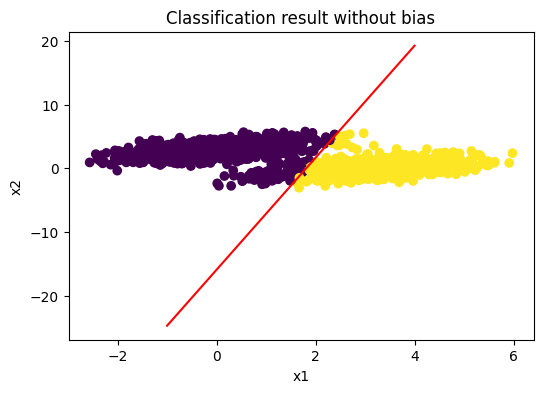

Final loss without bias: 0.0870751366019249


In [108]:
predictions_no_bias = model_no_bias(inputs, W_no_bias)

plt.figure(figsize=(6, 4))

plt.scatter(
    inputs[:, 0],
    inputs[:, 1],
    c=predictions_no_bias[:, 0] > 0.5
)

x_plot = np.linspace(-1, 4, 100)
y_plot = (
    -W_no_bias[0] / W_no_bias[1] * x_plot
    + 0.5 / W_no_bias[1]
)

plt.plot(x_plot, y_plot, "-r")

plt.title("Classification result without bias")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

print("Final loss without bias:", float(loss_no_bias))

Without the bias term, the linear classifier becomes more constrained because
the decision boundary cannot be shifted freely. In this experiment, the loss
remained higher and the classification boundary was less flexible than the
model with a bias term.

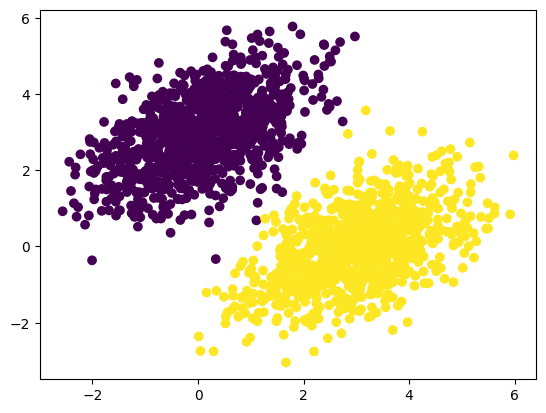

In [31]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

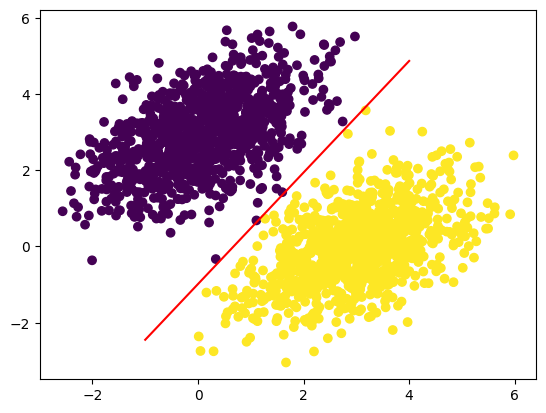

In [32]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

#### What makes the TensorFlow approach unique

### Introduction to PyTorch

#### First steps with PyTorch

##### Tensors and parameters in PyTorch

###### Constant tensors

In [33]:
import torch
torch.ones(size=(2, 1))

tensor([[1.],
        [1.]])

In [34]:
torch.zeros(size=(2, 1))

tensor([[0.],
        [0.]])

In [35]:
torch.tensor([1, 2, 3], dtype=torch.float32)

tensor([1., 2., 3.])

###### Random tensors

In [36]:
torch.normal(
mean=torch.zeros(size=(3, 1)),
std=torch.ones(size=(3, 1)))

tensor([[ 1.0769],
        [-0.8449],
        [ 0.4183]])

In [37]:
torch.rand(3, 1)

tensor([[0.5028],
        [0.8020],
        [0.8282]])

###### Tensor assignment and the Parameter class

In [38]:
x = torch.zeros(size=(2, 1))
x[0, 0] = 1.
x

tensor([[1.],
        [0.]])

In [39]:
x = torch.zeros(size=(2, 1))
p = torch.nn.parameter.Parameter(data=x)

##### Tensor operations: Doing math in PyTorch

In [40]:
a = torch.ones((2, 2))
b = torch.square(a)
c = torch.sqrt(a)
d = b + c
e = torch.matmul(a, b)
f = torch.cat((a, b), dim=0)

In [41]:
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

##### Computing gradients with PyTorch

In [42]:
input_var = torch.tensor(3.0, requires_grad=True)
result = torch.square(input_var)
result.backward()
gradient = input_var.grad
gradient

tensor(6.)

In [43]:
result = torch.square(input_var)
result.backward()
input_var.grad

tensor(12.)

In [44]:
input_var.grad = None

In [97]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

result = x**2 * y + x * y + 3 * y
result.backward()

x.grad, y.grad

(tensor(5.), tensor(9.))

In [98]:
x = torch.tensor([[1., 4., 3.]])

W = torch.rand(3, 2)
W.requires_grad = True

b = torch.zeros(2)
b.requires_grad = True

result = torch.matmul(x, W) + b
result.sum().backward()

W.grad, b.grad

(tensor([[1., 1.],
         [4., 4.],
         [3., 3.]]),
 tensor([1., 1.]))

In [99]:
W.grad = None
b.grad = None

result = torch.pow(torch.matmul(x, W) + b, 3)
result.sum().backward()

W.grad, b.grad

(tensor([[ 31.5753, 101.6963],
         [126.3013, 406.7850],
         [ 94.7259, 305.0887]]),
 tensor([ 31.5753, 101.6963]))

#### An end-to-end example: A linear classifier in pure PyTorch

In [45]:
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

In [46]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

In [47]:
def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

In [48]:
learning_rate = 0.1

def training_step(inputs, targets, W, b):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad
    with torch.no_grad():
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate
    W.grad = None
    b.grad = None
    return loss

##### Packaging state and computation with the Module class

In [49]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

In [50]:
model = LinearModel()

In [51]:
torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

In [52]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [53]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()
    return loss

##### Making PyTorch modules fast using compilation

In [54]:
compiled_model = torch.compile(model)

In [55]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

#### What makes the PyTorch approach unique

### Introduction to JAX

#### First steps with JAX

#### Tensors in JAX

In [56]:
from jax import numpy as jnp
jnp.ones(shape=(2, 1))

Array([[1.],
       [1.]], dtype=float32)

In [57]:
jnp.zeros(shape=(2, 1))

Array([[0.],
       [0.]], dtype=float32)

In [58]:
jnp.array([1, 2, 3], dtype="float32")

Array([1., 2., 3.], dtype=float32)

#### Random number generation in JAX

In [59]:
np.random.normal(size=(3,))

array([-1.64700344, -2.14670036,  0.0607476 ])

In [60]:
np.random.normal(size=(3,))

array([-0.51253335, -1.00840319,  0.14072276])

In [61]:
def apply_noise(x, seed):
    np.random.seed(seed)
    x = x * np.random.normal((3,))
    return x

seed = 1337
y = apply_noise(x, seed)
seed += 1
z = apply_noise(x, seed)

/tmp/ipykernel_553/2654806653.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x = x * np.random.normal((3,))


In [62]:
import jax

seed_key = jax.random.key(1337)

In [63]:
seed_key = jax.random.key(0)
jax.random.normal(seed_key, shape=(3,))

Array([ 1.6226422 ,  2.0252647 , -0.43359444], dtype=float32)

In [64]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [65]:
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [66]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [67]:
new_seed_key = jax.random.split(seed_key, num=1)[0]
jax.random.normal(new_seed_key, shape=(3,))

Array([-0.49093357, -0.9478693 , -1.775197  ], dtype=float32)

##### Tensor assignment

In [68]:
x = jnp.array([1, 2, 3], dtype="float32")
new_x = x.at[0].set(10)

##### Tensor operations: Doing math in JAX

In [69]:
a = jnp.ones((2, 2))
b = jnp.square(a)
c = jnp.sqrt(a)
d = b + c
e = jnp.matmul(a, b)
e *= d

In [70]:
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

##### Computing gradients with JAX

In [71]:
def compute_loss(input_var):
    return jnp.square(input_var)

In [72]:
grad_fn = jax.grad(compute_loss)

In [73]:
input_var = jnp.array(3.0)
grad_of_loss_wrt_input_var = grad_fn(input_var)

##### JAX gradient-computation best practices

###### Returning the loss value

In [74]:
grad_fn = jax.value_and_grad(compute_loss)
output, grad_of_loss_wrt_input_var = grad_fn(input_var)

###### Getting gradients for a complex function

###### Returning auxiliary outputs

##### Making JAX functions fast with @jax.jit

In [75]:
@jax.jit
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure JAX

In [76]:
def model(inputs, W, b):
    return jnp.matmul(inputs, W) + b

def mean_squared_error(targets, predictions):
    per_sample_losses = jnp.square(targets - predictions)
    return jnp.mean(per_sample_losses)

In [77]:
def compute_loss(state, inputs, targets):
    W, b = state
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    return loss

In [78]:
grad_fn = jax.value_and_grad(compute_loss)

In [79]:
learning_rate = 0.1

@jax.jit
def training_step(inputs, targets, W, b):
    loss, grads = grad_fn((W, b), inputs, targets)
    grad_wrt_W, grad_wrt_b = grads
    W = W - grad_wrt_W * learning_rate
    b = b - grad_wrt_b * learning_rate
    return loss, W, b

In [80]:
input_dim = 2
output_dim = 1

W = jax.numpy.array(np.random.uniform(size=(input_dim, output_dim)))
b = jax.numpy.array(np.zeros(shape=(output_dim,)))
state = (W, b)
for step in range(40):
    loss, W, b = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 3.4389
Loss at step 1: 0.2005
Loss at step 2: 0.1153
Loss at step 3: 0.0993
Loss at step 4: 0.0918
Loss at step 5: 0.0859
Loss at step 6: 0.0806
Loss at step 7: 0.0757
Loss at step 8: 0.0713
Loss at step 9: 0.0672
Loss at step 10: 0.0635
Loss at step 11: 0.0602
Loss at step 12: 0.0571
Loss at step 13: 0.0543
Loss at step 14: 0.0517
Loss at step 15: 0.0493
Loss at step 16: 0.0472
Loss at step 17: 0.0452
Loss at step 18: 0.0434
Loss at step 19: 0.0418
Loss at step 20: 0.0403
Loss at step 21: 0.0389
Loss at step 22: 0.0377
Loss at step 23: 0.0366
Loss at step 24: 0.0355
Loss at step 25: 0.0346
Loss at step 26: 0.0337
Loss at step 27: 0.0329
Loss at step 28: 0.0322
Loss at step 29: 0.0315
Loss at step 30: 0.0309
Loss at step 31: 0.0304
Loss at step 32: 0.0299
Loss at step 33: 0.0294
Loss at step 34: 0.0290
Loss at step 35: 0.0286
Loss at step 36: 0.0282
Loss at step 37: 0.0279
Loss at step 38: 0.0276
Loss at step 39: 0.0274


#### What makes the JAX approach unique

### Introduction to Keras

#### First steps with Keras

##### Picking a backend framework

In [81]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras

#### Layers: The building blocks of deep learning

##### The base `Layer` class in Keras

In [82]:
import keras

class SimpleDense(keras.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation

    def build(self, input_shape):
        batch_dim, input_dim = input_shape
        self.W = self.add_weight(
            shape=(input_dim, self.units), initializer="random_normal"
        )
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):
        y = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

In [83]:
my_dense = SimpleDense(units=32, activation=keras.ops.relu)
input_tensor = keras.ops.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


##### Automatic shape inference: Building layers on the fly

In [84]:
from keras import layers

layer = layers.Dense(32, activation="relu")

In [85]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

In [86]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

#### From layers to models

#### The "compile" step: Configuring the learning process

In [87]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer="rmsprop",
    loss="mean_squared_error",
    metrics=["accuracy"],
)

In [88]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

#### Picking a loss function

#### Understanding the fit method

In [89]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128,
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - binary_accuracy: 0.7065 - loss: 1.3022
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7240 - loss: 1.1453
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7320 - loss: 1.0202
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7470 - loss: 0.9075
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7660 - loss: 0.8035


In [90]:
history.history

{'binary_accuracy': [0.7065000534057617,
  0.7240000367164612,
  0.7320000529289246,
  0.7470000386238098,
  0.7660000324249268],
 'loss': [1.3021680116653442,
  1.145296335220337,
  1.0201735496520996,
  0.9075089693069458,
  0.8034749031066895]}

#### Monitoring loss and metrics on validation data

In [91]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets),
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.8650 - loss: 0.5522 - val_binary_accuracy: 0.6533 - val_loss: 0.3076
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9643 - loss: 0.0692 - val_binary_accuracy: 0.9650 - val_loss: 0.1020
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9543 - loss: 0.0751 - val_binary_accuracy: 0.8767 - val_loss: 0.2081
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9707 - loss: 0.0642 - val_binary_accuracy: 0.8333 - val_loss: 0.1652
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9514 - loss: 0.0750 - val_binary_accuracy: 0.7100 - val_loss: 0.3267


#### Inference: Using a model after training

In [92]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[ 0.5587949 ]
 [-0.515287  ]
 [ 0.7637634 ]
 [ 0.02518001]
 [ 0.6395084 ]
 [-0.75424397]
 [ 1.1228974 ]
 [ 0.42731905]
 [ 0.6408583 ]
 [ 0.06771648]]
